Adarsh Sapkota (2407043)

In [ ]:
import os
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_dir = "/content/drive/My Drive/data/week5/FruitinAmazon/train/"
test_dir = "/content/drive/My Drive/data/week5FruitinAmazon/test/"

In [ ]:
from PIL import Image, UnidentifiedImageError

corrupted_images = [] # List to store corrupted images path

# Loop through each class folder and check for corrupted images
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path): # Ensure it’s a valid directory
    images = os.listdir(class_path)
    for img_name in images:
      img_path = os.path.join(class_path, img_name)
      try:
        with Image.open(img_path) as img:
          img.verify() # Verify image integrity
      except (IOError, UnidentifiedImageError):
        corrupted_images.append(img_path)
# Print results
if corrupted_images:
  print("\nCorrupted Images Found:")
  for img in corrupted_images:
    print(img)
else:
  print("\nNo corrupted images found.")



Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
# Select one image randomly from each class
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = os.listdir(class_path)

    if len(image_files) > 0:
        random_image = random.choice(image_files)
        img_path = os.path.join(class_path, random_image)

        img = Image.open(img_path).convert("RGB")  # Convert to RGB format
        img = img.resize((69, 69))  # Resize for visualization

        selected_images.append(np.array(img))
        selected_labels.append(class_name)

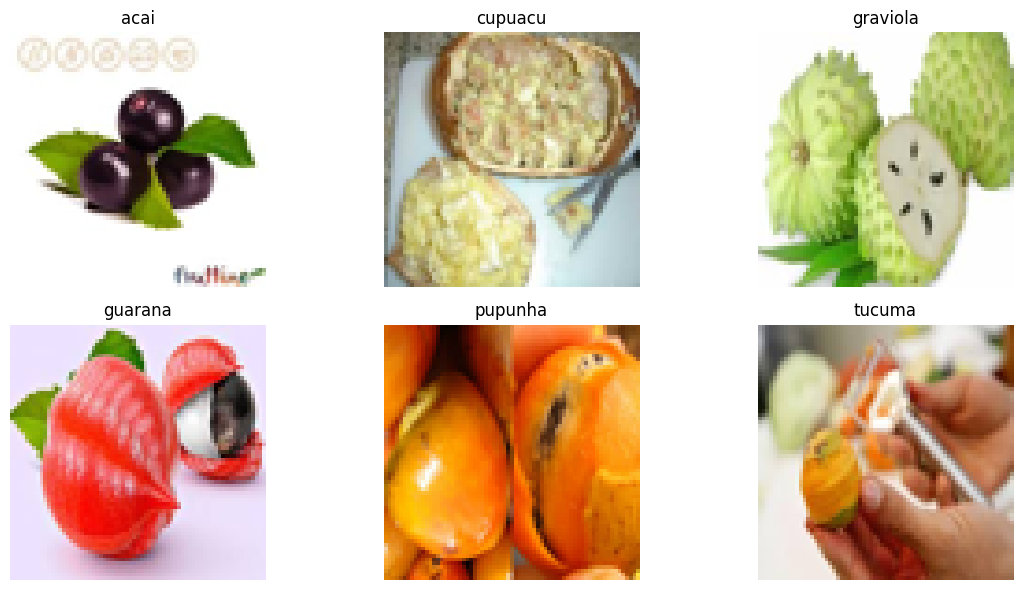

In [ ]:
# Plot images in a grid format with two rows
fig, axes = plt.subplots(nrows=2, ncols=len(selected_images)//2, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(selected_images[i])
    ax.set_title(selected_labels[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def remove_corrupted_images(directory):
    corrupted_images = []  # List to store corrupted image paths

    # Iterate through each class folder
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)

        if not os.path.isdir(class_path):  # Skip non-folder files
            continue

        # Iterate through all images in the class folder
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                # Try opening the image
                with Image.open(img_path) as img:
                    img.verify()  # Verify the image is valid

            except (IOError, SyntaxError):  # Catch corrupted images
                corrupted_images.append(img_path)
                os.remove(img_path)  # Delete the corrupted image
                print(f"Removed corrupted image: {img_path}")

    # Print final summary
    if corrupted_images:
        print(f"\nTotal {len(corrupted_images)} corrupted images removed Sucessfully.")
    else:
        print("No corrupted images found in File.")

In [ ]:
remove_corrupted_images(train_dir)

No corrupted images found in File.


In [ ]:
import tensorflow as tf

# Define image size and batch size
img_height = 224 # Example image height
img_width = 224 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
      train_dir,
      labels='inferred',
      label_mode='int',
      image_size=(img_height, img_width),
      interpolation='nearest',
      batch_size=batch_size,
      shuffle=True,
      validation_split=validation_split,
      subset='training',
      seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset='validation',
  seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# # Define number of output classes
num_classes = 6  # Change based on dataset

# # Build CNN Model
# model = keras.Sequential([
#     # Convolutional Layer 1
#     layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=1, input_shape=(128, 128, 3)),
#     layers.MaxPooling2D((2, 2), strides=2),

#     # Convolutional Layer 2
#     layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=1),
#     layers.MaxPooling2D((2, 2), strides=2),

#     # Flatten Layer
#     layers.Flatten(),

#     # Fully Connected Layers
#     layers.Dense(64, activation='relu'),
#     layers.Dense(128, activation='relu'),

#     # Output Layer
#     layers.Dense(num_classes, activation='softmax')
# ])

# # Compile the Model using SGD Optimizer


# # Print Model Summary
# model.summary()


# Define the model
model = keras.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=1, input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=1),
    layers.MaxPooling2D((2, 2), strides=2),

    # Flatten Layer to convert 3D output of convolution to 1D input for dense layers
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')  # num_classes based on your dataset
])

# Compile the model with Adam optimizer, sparse categorical crossentropy, and accuracy metric
model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary to see the input-output shapes at each layer
model.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       6,422,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,441,830 (24.57 MB)

 Trainable params: 6,441,830 (24.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_cb = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stopping_cb = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    train_ds,  # Training dataset
    validation_data=val_ds,  # Validation dataset
    epochs=50,  # Number of epochs
    batch_size=16,  # Batch size
    callbacks=[checkpoint_cb, early_stopping_cb]  # Callbacks
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1453 - loss: 2.2614

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.1437 - loss: 2.3106 - val_accuracy: 0.6667 - val_loss: 1.6007
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3137 - loss: 1.7331

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.3220 - loss: 1.7293 - val_accuracy: 0.7222 - val_loss: 1.5518
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4537 - loss: 1.6174

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4618 - loss: 1.6082 - val_accuracy: 0.8333 - val_loss: 1.2725
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4091 - loss: 1.3628

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4145 - loss: 1.3564 - val_accuracy: 0.7778 - val_loss: 1.0061
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6545 - loss: 1.0114

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6576 - loss: 1.0057 - val_accuracy: 0.8333 - val_loss: 0.6057
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7361 - loss: 0.7565 - val_accuracy: 0.5000 - val_loss: 1.2413
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7530 - loss: 0.6437 - val_accuracy: 0.6111 - val_loss: 0.8734
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9398 - loss: 0.3784

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9410 - loss: 0.3745 - val_accuracy: 0.9444 - val_loss: 0.2228
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9674 - loss: 0.2002 - val_accuracy: 0.8333 - val_loss: 0.3780
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 1.0000 - loss: 0.0863 - val_accuracy: 0.8333 - val_loss: 0.5482
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 1.0000 - loss: 0.0719 - val_accuracy: 0.8889 - val_loss: 0.2758
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 1.0000 - loss: 0.0133 - val_accuracy: 0.9444 - val_loss: 0.2824
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 1.0000 - loss: 0.0123 - val_accuracy: 0.8889 - val_loss: 0.3322
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.8333 - val_loss: 0.5767
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.8333 - val_loss: 0.6740
Epoch 16/50
3/3 ━━━━━

In [ ]:
# Evaluate the model on the test set
dataset_test = "/content/drive/My Drive/data/week5/FruitinAmazon/train/"
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_test,  # Directory with test data
    image_size=(224, 224),
    batch_size=16
)

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")


Found 90 files belonging to 6 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - accuracy: 0.8208 - loss: 50.5256
Test Loss: 54.756500244140625
Test Accuracy: 0.800000011920929


In [ ]:
# Save the model in the new Keras format
model.save('my_model.keras')


In [ ]:
# Load the saved model in the new Keras format
loaded_model = tf.keras.models.load_model('my_model.keras')

# Re-evaluate the loaded model on the test set
loaded_test_loss, loaded_test_acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model - Test Loss: {loaded_test_loss}")
print(f"Loaded Model - Test Accuracy: {loaded_test_acc}")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step - accuracy: 0.7957 - loss: 66.3414
Loaded Model - Test Loss: 54.756500244140625
Loaded Model - Test Accuracy: 0.800000011920929


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Make predictions
predictions = model.predict(test_ds)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=-1)

# Get true labels
true_labels = np.concatenate([y for x, y in test_ds], axis=0)

# Generate the classification report
report = classification_report(true_labels, predicted_labels)
print(report)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step
              precision    recall  f1-score   support

           0       0.07      0.07      0.07        15
           1       0.11      0.13      0.12        15
           2       0.33      0.20      0.25        15
           3       0.18      0.13      0.15        15
           4       0.13      0.13      0.13        15
           5       0.09      0.13      0.11        15

    accuracy                           0.13        90
   macro avg       0.15      0.13      0.14        90
weighted avg       0.15      0.13      0.14        90



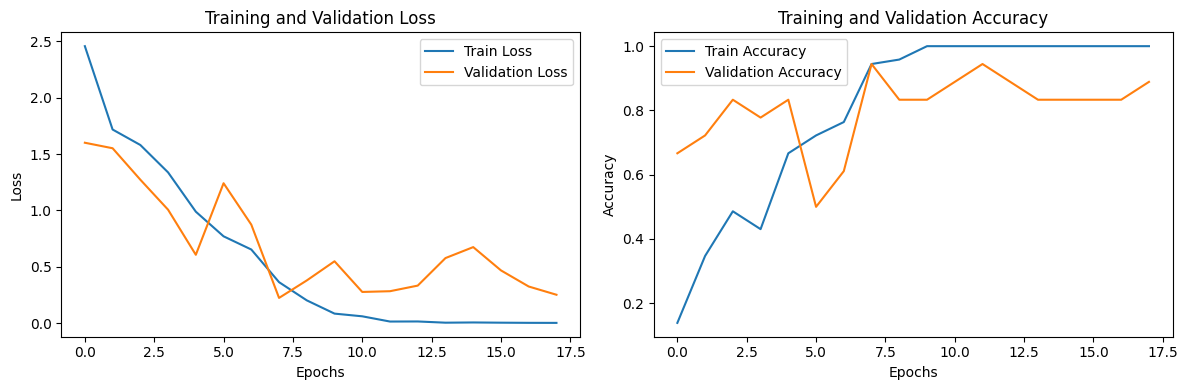

In [ ]:
# Plot training history (loss and accuracy)
plt.figure(figsize=(12, 4))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Task 1: Improving the Model
- Apply Data Augmentation
- Use a deeper model with Batch Normalization and Dropout
- Analyze Model Summary and Training Behavior

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rescale=1./255
)

# Improved Model with Batch Normalization and Dropout
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,248,138 (84.87 MB)

 Trainable params: 22,247,690 (84.87 MB)

 Non-trainable params: 448 (1.75 KB)

## Task 2: Transfer Learning with VGG16
- Load Pretrained VGG16 Model
- Freeze its layers and add custom classification layers
- Train and Evaluate the model


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Load Pretrained VGG16 Model (without top layer)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(10, activation='softmax')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=x)

# Compile and Train the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1024)                │         525,3

 Total params: 15,250,250 (58.18 MB)

 Trainable params: 535,562 (2.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)